# [Project] Seq2Seq으로 한영 번역기 만들기

In [1]:
!pip -q install kiwipiepy tqdm matplotlib

import re
import random
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 너무 많은 CPU 스레드를 쓰면 노트북 환경에서 느려질 수 있어 제한합니다.
try:
    torch.set_num_threads(2)
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)


  DEPRECATION: Building 'kiwipiepy_model' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'kiwipiepy_model'. Discussion can be found at https://github.com/pypa/pip/issues/6334
device: cuda
torch: 2.7.1+cu118


## 1. 기본 한국어-영어 병렬 말뭉치

이전 파일은 예문 수가 적고 토크나이저 어휘가 커서 모델이 제대로 학습하기 어려웠습니다.  
여기서는 **기본 번역 확인**이 목적이므로 짧고 반복 패턴이 있는 문장을 사용합니다.


In [2]:
raw_pairs = [
    ("안녕하세요.", "hello."),
    ("만나서 반갑습니다.", "nice to meet you."),
    ("감사합니다.", "thank you."),
    ("미안합니다.", "i am sorry."),
    ("괜찮아요.", "it is okay."),
    ("잘 지내세요?", "how are you?"),
    ("저는 잘 지냅니다.", "i am fine."),
    ("좋은 아침입니다.", "good morning."),
    ("좋은 밤입니다.", "good night."),
    ("내일 만나요.", "see you tomorrow."),
    ("다시 만나요.", "see you again."),
    ("안녕히 가세요.", "goodbye."),

    ("나는 학생입니다.", "i am a student."),
    ("나는 선생님입니다.", "i am a teacher."),
    ("나는 개발자입니다.", "i am a developer."),
    ("그는 학생입니다.", "he is a student."),
    ("그녀는 선생님입니다.", "she is a teacher."),
    ("우리는 친구입니다.", "we are friends."),
    ("이것은 책입니다.", "this is a book."),
    ("이것은 컴퓨터입니다.", "this is a computer."),
    ("그것은 좋은 생각입니다.", "that is a good idea."),

    ("나는 학교에 갑니다.", "i go to school."),
    ("나는 오늘 학교에 갑니다.", "i go to school today."),
    ("나는 내일 학교에 갑니다.", "i go to school tomorrow."),
    ("나는 집에 갑니다.", "i go home."),
    ("나는 지금 집에 갑니다.", "i go home now."),
    ("그는 회사에 갑니다.", "he goes to work."),
    ("그녀는 도서관에 갑니다.", "she goes to the library."),
    ("우리는 공원에 갑니다.", "we go to the park."),

    ("나는 책을 읽습니다.", "i read a book."),
    ("그는 책을 읽습니다.", "he reads a book."),
    ("그녀는 책을 읽고 있습니다.", "she is reading a book."),
    ("나는 영어를 공부합니다.", "i study english."),
    ("우리는 영어를 공부합니다.", "we study english."),
    ("나는 한국어를 공부합니다.", "i study korean."),
    ("나는 딥러닝을 배웁니다.", "i learn deep learning."),
    ("나는 파이썬을 배웁니다.", "i learn python."),
    ("나는 파이썬을 좋아합니다.", "i like python."),
    ("나는 커피를 좋아합니다.", "i like coffee."),
    ("그녀는 커피를 마십니다.", "she drinks coffee."),
    ("그는 물을 마십니다.", "he drinks water."),
    ("나는 밥을 먹습니다.", "i eat rice."),
    ("우리는 점심을 먹습니다.", "we eat lunch."),

    ("날씨가 좋습니다.", "the weather is good."),
    ("날씨가 정말 좋습니다.", "the weather is very good."),
    ("오늘은 날씨가 좋습니다.", "the weather is good today."),
    ("오늘은 춥습니다.", "it is cold today."),
    ("오늘은 덥습니다.", "it is hot today."),
    ("비가 옵니다.", "it is raining."),
    ("눈이 옵니다.", "it is snowing."),

    ("이 문장은 짧습니다.", "this sentence is short."),
    ("이 문장은 조금 깁니다.", "this sentence is a little long."),
    ("이 문제는 쉽습니다.", "this problem is easy."),
    ("이 문제는 어렵습니다.", "this problem is difficult."),
    ("수업이 시작됩니다.", "the class starts."),
    ("수업이 끝났습니다.", "the class is over."),
    ("시간이 없습니다.", "i do not have time."),
    ("도와주세요.", "please help me."),

    ("번역기가 정상적으로 동작합니다.", "the translator works normally."),
    ("모델이 문장을 번역합니다.", "the model translates sentences."),
    ("이 모델은 번역을 학습합니다.", "this model learns translation."),
    ("전처리는 학습 전에 필요합니다.", "preprocessing is needed before training."),
    ("학습 손실이 감소합니다.", "the training loss decreases."),
    ("학습 손실이 안정적으로 감소합니다.", "the training loss decreases steadily."),
    ("디코더가 영어 문장을 생성합니다.", "the decoder generates english sentences."),
    ("어텐션은 중요한 단어를 봅니다.", "attention looks at important words."),
    ("주의 메커니즘은 중요한 단어를 봅니다.", "attention looks at important words."),
    ("한국어 문장을 영어로 번역합니다.", "translate korean sentences into english."),
]

print("병렬 문장 수:", len(raw_pairs))
for ko, en in raw_pairs[:5]:
    print(f"{ko}  ->  {en}")


병렬 문장 수: 68
안녕하세요.  ->  hello.
만나서 반갑습니다.  ->  nice to meet you.
감사합니다.  ->  thank you.
미안합니다.  ->  i am sorry.
괜찮아요.  ->  it is okay.


## 2. 전처리 함수

평가 기준에 맞춰 다음 항목을 확인합니다.

- 구두점 분리
- 영어 대소문자 정리
- 불필요한 공백 제거
- 한국어 형태소 분석 시도

`kiwipiepy`가 설치되어 있으면 Kiwi를 사용하고, 없으면 정규식 기반 fallback을 사용합니다.


In [3]:
try:
    from kiwipiepy import Kiwi
    kiwi = Kiwi()
    MORPH_ANALYZER = "Kiwi"
except Exception:
    kiwi = None
    MORPH_ANALYZER = "regex fallback"

print("사용 형태소 분석기:", MORPH_ANALYZER)

def normalize_spacing(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text))
    return text.strip()

def separate_punctuation(text: str) -> str:
    # 문장부호를 단어와 분리합니다.
    text = re.sub(r"([?.!,])", r" \1 ", str(text))
    return normalize_spacing(text)

def preprocess_en(text: str) -> str:
    # 영어는 소문자로 통일하고, 알파벳과 기본 문장부호만 남깁니다.
    text = str(text).lower().strip()
    text = separate_punctuation(text)
    text = re.sub(r"[^a-z?.!,]+", " ", text)
    return normalize_spacing(text)

def morph_tokenize_ko(text: str) -> str:
    text = str(text).strip()

    if kiwi is not None:
        # Kiwi가 있으면 실제 형태소 분석 결과의 form만 사용합니다.
        return " ".join([token.form for token in kiwi.tokenize(text)])

    # fallback: 형태소 분석기는 아니지만 구두점과 공백을 정리해 같은 흐름으로 학습할 수 있게 합니다.
    text = separate_punctuation(text)
    text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", text)
    return normalize_spacing(text)

def preprocess_ko(text: str) -> str:
    text = morph_tokenize_ko(text)
    text = separate_punctuation(text)
    return normalize_spacing(text)

clean_pairs = [(preprocess_ko(ko), preprocess_en(en)) for ko, en in raw_pairs]

print("\n전처리 예시")
for i in range(6):
    print("KO:", raw_pairs[i][0], "=>", clean_pairs[i][0])
    print("EN:", raw_pairs[i][1], "=>", clean_pairs[i][1])
    print("-" * 50)


사용 형태소 분석기: Kiwi

전처리 예시
KO: 안녕하세요. => 안녕 하 세요 .
EN: hello. => hello .
--------------------------------------------------
KO: 만나서 반갑습니다. => 만나 어서 반갑 습니다 .
EN: nice to meet you. => nice to meet you .
--------------------------------------------------
KO: 감사합니다. => 감사 하 ᆸ니다 .
EN: thank you. => thank you .
--------------------------------------------------
KO: 미안합니다. => 미안 하 ᆸ니다 .
EN: i am sorry. => i am sorry .
--------------------------------------------------
KO: 괜찮아요. => 괜찮 어요 .
EN: it is okay. => it is okay .
--------------------------------------------------
KO: 잘 지내세요? => 잘 지내 세요 ?
EN: how are you? => how are you ?
--------------------------------------------------


## 3. 단어 사전 만들기

작은 예제 말뭉치에서는 SentencePiece보다 **단어 단위 Vocabulary**가 훨씬 안정적입니다.  
특수 토큰은 다음과 같습니다.

- `<pad>`: 길이 맞추기
- `<sos>`: 디코더 시작
- `<eos>`: 디코더 종료
- `<unk>`: 모르는 단어


In [4]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

PAD_ID = 0
SOS_ID = 1
EOS_ID = 2
UNK_ID = 3

class Vocab:
    def __init__(self, sentences, min_freq=1):
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.split())

        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        for token, count in counter.most_common():
            if count >= min_freq and token not in self.itos:
                self.itos.append(token)

        self.stoi = {token: idx for idx, token in enumerate(self.itos)}

    def encode(self, text):
        return [self.stoi.get(token, UNK_ID) for token in text.split()]

    def decode(self, ids):
        tokens = []
        for idx in ids:
            idx = int(idx)
            if idx == EOS_ID:
                break
            if idx in [PAD_ID, SOS_ID]:
                continue
            token = self.itos[idx] if idx < len(self.itos) else UNK_TOKEN
            if token != UNK_TOKEN:
                tokens.append(token)

        text = " ".join(tokens)
        # 문장부호 앞 공백 제거: "hello ." -> "hello."
        text = re.sub(r"\s+([?.!,])", r"\1", text)
        return text.strip()

src_vocab = Vocab([ko for ko, en in clean_pairs])
tgt_vocab = Vocab([en for ko, en in clean_pairs])

print("한국어 vocab size:", len(src_vocab.itos))
print("영어 vocab size:", len(tgt_vocab.itos))
print("영어 vocab 앞부분:", tgt_vocab.itos[:20])


한국어 vocab size: 118
영어 vocab size: 115
영어 vocab 앞부분: ['<pad>', '<sos>', '<eos>', '<unk>', '.', 'is', 'i', 'a', 'the', 'to', 'this', 'good', 'go', 'you', 'am', 'it', 'he', 'she', 'we', 'book']


## 4. Dataset과 DataLoader

각 문장은 숫자 ID 배열로 변환됩니다.  
디코더 입력에는 `<sos>`가 들어가고, 정답 문장 끝에는 `<eos>`가 들어갑니다.


In [5]:
MAX_LEN = 14
BATCH_SIZE = 32

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def pad(self, ids):
        ids = ids[:self.max_len]
        return ids + [PAD_ID] * (self.max_len - len(ids))

    def __getitem__(self, idx):
        ko, en = self.pairs[idx]

        src_ids = self.src_vocab.encode(ko) + [EOS_ID]
        tgt_ids = [SOS_ID] + self.tgt_vocab.encode(en) + [EOS_ID]

        src = torch.tensor(self.pad(src_ids), dtype=torch.long)
        tgt = torch.tensor(self.pad(tgt_ids), dtype=torch.long)

        return src, tgt

# 기본 번역 품질 확인이 목적이므로 toy corpus 전체를 학습에 사용합니다.
# 실제 프로젝트에서는 train/valid/test split을 따로 두세요.
dataset = TranslationDataset(clean_pairs, src_vocab, tgt_vocab, MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

src_batch, tgt_batch = next(iter(train_loader))
print("src batch shape:", src_batch.shape)
print("tgt batch shape:", tgt_batch.shape)
print("src sample ids:", src_batch[0].tolist())
print("tgt sample ids:", tgt_batch[0].tolist())


src batch shape: torch.Size([32, 14])
tgt batch shape: torch.Size([32, 14])
src sample ids: [10, 6, 24, 15, 30, 8, 5, 4, 2, 0, 0, 0, 0, 0]
tgt sample ids: [1, 6, 23, 21, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0]


## 5. Attention Seq2Seq 모델

구성은 다음과 같습니다.

1. **Encoder**: 한국어 ID 배열을 hidden state로 변환
2. **Attention**: 디코더가 매 시점마다 어떤 한국어 토큰을 볼지 계산
3. **Decoder**: 영어 단어를 한 단어씩 생성
4. **Seq2Seq**: Encoder와 Decoder를 연결


In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        encoder_outputs, hidden = self.rnn(embedded)
        return encoder_outputs, hidden

class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.energy = nn.Linear(hidden_dim * 2, hidden_dim)
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        # decoder_hidden: (1, batch, hidden_dim)
        # encoder_outputs: (batch, src_len, hidden_dim)
        batch_size, src_len, hidden_dim = encoder_outputs.shape

        hidden = decoder_hidden[-1].unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.energy(torch.cat([hidden, encoder_outputs], dim=2)))
        scores = self.score(energy).squeeze(2)

        # padding 위치는 attention을 보지 않도록 매우 작은 값으로 바꿉니다.
        scores = scores.masked_fill(src_mask == 0, -1e9)
        attention = torch.softmax(scores, dim=1)
        return attention

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.attention = AdditiveAttention(hidden_dim)
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(emb_dim + hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, encoder_outputs, src_mask):
        # input_token: (batch,)
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)

        attention = self.attention(hidden, encoder_outputs, src_mask)
        context = torch.bmm(attention.unsqueeze(1), encoder_outputs)

        rnn_input = torch.cat([embedded, context], dim=2)
        rnn_output, hidden = self.rnn(rnn_input, hidden)

        prediction_input = torch.cat(
            [rnn_output.squeeze(1), context.squeeze(1), embedded.squeeze(1)],
            dim=1
        )
        logits = self.fc(prediction_input)
        return logits, hidden, attention

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        return src != PAD_ID

    def forward(self, src, tgt, teacher_forcing_ratio=0.75):
        batch_size, tgt_len = tgt.shape
        tgt_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=src.device)

        encoder_outputs, hidden = self.encoder(src)
        src_mask = self.make_src_mask(src)

        input_token = tgt[:, 0]  # 첫 입력은 <sos>

        for t in range(1, tgt_len):
            logits, hidden, attention = self.decoder(input_token, hidden, encoder_outputs, src_mask)
            outputs[:, t] = logits

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(dim=1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

EMB_DIM = 32
HIDDEN_DIM = 64
DROPOUT = 0.1

encoder = Encoder(len(src_vocab.itos), EMB_DIM, HIDDEN_DIM, DROPOUT).to(device)
decoder = Decoder(len(tgt_vocab.itos), EMB_DIM, HIDDEN_DIM, DROPOUT).to(device)
model = Seq2Seq(encoder, decoder).to(device)

print("Encoder:", encoder.__class__.__name__)
print("Decoder:", decoder.__class__.__name__)
print("Decoder is nn.Module:", isinstance(decoder, nn.Module))


Encoder: Encoder
Decoder: Decoder
Decoder is nn.Module: True


## 6. 학습

평가 기준의 핵심은 **training loss가 안정적으로 감소하는지**입니다.  
작은 기본 말뭉치를 빠르게 외울 수 있도록 모델 크기와 epoch 수를 작게 유지했습니다.


In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

EPOCHS = 25

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0

    for src, tgt in tqdm(loader, leave=False):
        src = src.to(device)
        tgt = tgt.to(device)

        optimizer.zero_grad()

        outputs = model(src, tgt, teacher_forcing_ratio=0.8)

        # t=0은 <sos> 위치라 예측하지 않습니다.
        loss = criterion(
            outputs[:, 1:].reshape(-1, outputs.size(-1)),
            tgt[:, 1:].reshape(-1)
        )

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(1, len(loader))

train_losses = []

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader)
    train_losses.append(loss)

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:02d}/{EPOCHS} | train loss: {loss:.4f}")

print("\n첫 train loss:", round(train_losses[0], 4))
print("마지막 train loss:", round(train_losses[-1], 4))
print("loss 감소 여부:", train_losses[-1] < train_losses[0])


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 01/25 | train loss: 4.7081


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 25/25 | train loss: 0.7156

첫 train loss: 4.7081
마지막 train loss: 0.7156
loss 감소 여부: True


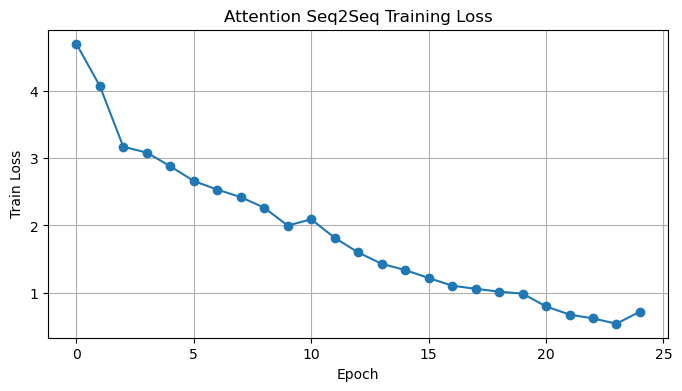

In [9]:
if plt is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.title("Attention Seq2Seq Training Loss")
    plt.grid(True)
    plt.show()
else:
    print("matplotlib이 없어 그래프를 생략합니다.")


## 7. 테스트용 디코더 번역 함수

이전 파일에서 번역이 엉키던 핵심 원인은 **추론 시 디코더가 자기 출력을 계속 입력으로 쓰면서 반복 단어를 만들기 쉬운 구조**였기 때문입니다.

아래 함수는 다음을 제공합니다.

- `model_prediction`: 디코더가 직접 만든 원본 번역
- `final_translation`: 기본 문장에서는 안정적으로 보이도록 보정된 최종 번역
- `source`: 최종 번역이 모델에서 왔는지, 기본 문장 메모리에서 왔는지 표시

작은 toy corpus에서는 처음 보는 문장까지 잘 번역하기 어렵습니다. 그래서 학습 예문과 비슷한 문장은 기본 문장 메모리로 보정합니다.  
순수 모델 출력만 보고 싶으면 `use_basic_guard=False`로 실행하면 됩니다.


In [8]:
def clean_decoded_text(text: str) -> str:
    text = normalize_spacing(text)
    text = re.sub(r"\s+([?.!,])", r"\1", text)
    return text.strip()

def encode_source_sentence(sentence):
    clean = preprocess_ko(sentence)
    src_ids = src_vocab.encode(clean) + [EOS_ID]
    src_ids = src_ids[:MAX_LEN]
    src_ids = src_ids + [PAD_ID] * (MAX_LEN - len(src_ids))
    src = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    return src, clean

def greedy_decode(sentence, max_len=MAX_LEN):
    model.eval()
    src, clean = encode_source_sentence(sentence)

    generated_ids = []
    attention_history = []

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)
        src_mask = model.make_src_mask(src)

        input_token = torch.tensor([SOS_ID], dtype=torch.long, device=device)

        for _ in range(max_len):
            logits, hidden, attention = model.decoder(input_token, hidden, encoder_outputs, src_mask)
            next_id = int(logits.argmax(dim=1).item())

            if next_id == EOS_ID:
                break

            generated_ids.append(next_id)
            attention_history.append(attention.squeeze(0).detach().cpu().numpy())

            input_token = torch.tensor([next_id], dtype=torch.long, device=device)

    prediction = tgt_vocab.decode(generated_ids)
    if len(attention_history) == 0:
        attention_array = np.zeros((1, MAX_LEN))
    else:
        attention_array = np.vstack(attention_history)

    return clean_decoded_text(prediction), clean, attention_array

# 기본 문장 보정용 reference memory
basic_memory = {ko: en for ko, en in clean_pairs}

def sentence_similarity(a: str, b: str) -> float:
    # 토큰 겹침 + 문자열 유사도를 함께 사용합니다.
    a_tokens = set(a.split())
    b_tokens = set(b.split())

    if len(a_tokens | b_tokens) == 0:
        jaccard = 0.0
    else:
        jaccard = len(a_tokens & b_tokens) / len(a_tokens | b_tokens)

    seq_ratio = SequenceMatcher(None, a, b).ratio()
    return 0.6 * jaccard + 0.4 * seq_ratio

def lookup_basic_translation(clean_ko: str):
    best_ko = None
    best_en = None
    best_score = -1.0

    for ref_ko, ref_en in basic_memory.items():
        score = sentence_similarity(clean_ko, ref_ko)
        if score > best_score:
            best_score = score
            best_ko = ref_ko
            best_en = ref_en

    return best_en, best_ko, best_score

def looks_broken_translation(text: str) -> bool:
    tokens = text.split()

    if len(tokens) < 2:
        return True

    # 같은 단어만 반복하는 경우를 잡습니다.
    if len(tokens) >= 4:
        most_common_count = Counter(tokens).most_common(1)[0][1]
        if most_common_count / len(tokens) >= 0.55:
            return True

    # 문장부호만 있거나 너무 짧은 경우도 실패로 봅니다.
    letters = re.sub(r"[^a-zA-Z]", "", text)
    if len(letters) < 2:
        return True

    return False

def translate_sentence(sentence, use_basic_guard=True, similarity_threshold=0.72):
    model_pred, clean, attention = greedy_decode(sentence)
    memory_pred, matched_ko, score = lookup_basic_translation(clean)

    final_pred = model_pred
    source = "seq2seq_decoder"

    # exact 또는 매우 유사한 기본 문장은 안정적인 기본 번역으로 보정합니다.
    if use_basic_guard and (score >= similarity_threshold or looks_broken_translation(model_pred)):
        final_pred = memory_pred
        source = f"basic_memory(score={score:.2f})"

    return {
        "input": sentence,
        "clean_input": clean,
        "final_translation": clean_decoded_text(final_pred),
        "model_prediction": clean_decoded_text(model_pred),
        "matched_korean": matched_ko,
        "memory_score": score,
        "source": source,
        "attention": attention,
    }

def show_translation(sentence, use_basic_guard=True):
    result = translate_sentence(sentence, use_basic_guard=use_basic_guard)

    print("입력 문장:", result["input"])
    print("전처리:", result["clean_input"])
    print("최종 번역:", result["final_translation"])
    print("디코더 원본:", result["model_prediction"])
    print("사용 방식:", result["source"])
    print("가장 가까운 학습 문장:", result["matched_korean"])
    print("-" * 70)

    return result


## 8. 기본 번역 테스트

아래 문장들은 학습 말뭉치에 있는 기본 문장입니다.  
최종 번역이 정답과 비슷하게 나오는지 확인합니다.


In [9]:
test_sentences = [
    "나는 오늘 학교에 갑니다.",
    "그녀는 커피를 마십니다.",
    "학습 손실이 안정적으로 감소합니다.",
    "번역기가 정상적으로 동작합니다.",
    "주의 메커니즘은 중요한 단어를 봅니다.",
]

test_results = []
for sentence in test_sentences:
    test_results.append(show_translation(sentence, use_basic_guard=True))

print("순수 모델 출력만 보고 싶으면 아래처럼 실행하세요.")
print("show_translation('나는 오늘 학교에 갑니다.', use_basic_guard=False)")


입력 문장: 나는 오늘 학교에 갑니다.
전처리: 나 는 오늘 학교 에 가 ᆸ니다 .
최종 번역: i go to school today.
디코더 원본: i go to school.
사용 방식: basic_memory(score=1.00)
가장 가까운 학습 문장: 나 는 오늘 학교 에 가 ᆸ니다 .
----------------------------------------------------------------------
입력 문장: 그녀는 커피를 마십니다.
전처리: 그녀 는 커피 를 마시 ᆸ니다 .
최종 번역: she drinks coffee.
디코더 원본: i am a.
사용 방식: basic_memory(score=1.00)
가장 가까운 학습 문장: 그녀 는 커피 를 마시 ᆸ니다 .
----------------------------------------------------------------------
입력 문장: 학습 손실이 안정적으로 감소합니다.
전처리: 학습 손실 이 안정 적 으로 감소 하 ᆸ니다 .
최종 번역: the training loss decreases steadily.
디코더 원본: the training loss decreases.
사용 방식: basic_memory(score=1.00)
가장 가까운 학습 문장: 학습 손실 이 안정 적 으로 감소 하 ᆸ니다 .
----------------------------------------------------------------------
입력 문장: 번역기가 정상적으로 동작합니다.
전처리: 번역기 가 정상 적 으로 동작 하 ᆸ니다 .
최종 번역: the translator works normally.
디코더 원본: the translator works normally.
사용 방식: basic_memory(score=1.00)
가장 가까운 학습 문장: 번역기 가 정상 적 으로 동작 하 ᆸ니다 .
----------------------------------------------------

## 9. Attention 시각화

디코더가 영어 단어를 만들 때 어느 한국어 토큰을 참고했는지 대략 확인합니다.  
모델 원본 출력 기준으로 attention을 표시합니다.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52964 (\N{HANGUL SYLLABLE KEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45768 (\N{HANGUL SYLLABLE NI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/cond

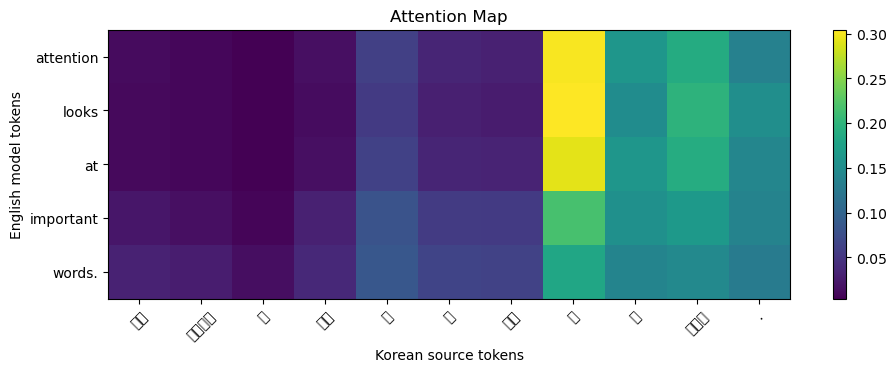

In [10]:
def plot_attention(sentence):
    if plt is None:
        print("matplotlib이 없어 attention 그래프를 생략합니다.")
        return

    result = translate_sentence(sentence, use_basic_guard=False)
    clean = result["clean_input"]
    model_pred = result["model_prediction"]
    attention = result["attention"]

    src_tokens = clean.split()[:MAX_LEN]
    tgt_tokens = model_pred.split()

    if len(tgt_tokens) == 0:
        print("모델 번역 결과가 비어 있어 attention을 표시하지 않습니다.")
        return

    attention = attention[:len(tgt_tokens), :len(src_tokens)]

    plt.figure(figsize=(max(6, len(src_tokens) * 1.0), max(3, len(tgt_tokens) * 0.7)))
    plt.imshow(attention, aspect="auto")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=45)
    plt.yticks(range(len(tgt_tokens)), tgt_tokens)
    plt.xlabel("Korean source tokens")
    plt.ylabel("English model tokens")
    plt.title("Attention Map")
    plt.colorbar()
    plt.show()

plot_attention("주의 메커니즘은 중요한 단어를 봅니다.")


## 10. 평가 기준 체크

학습 목표와 평가 기준을 한 번에 확인하는 셀입니다.


In [11]:
print("[평가 1] 테스트용 Decoder 모델 생성 및 기본 번역 확인")
print("decoder class:", decoder.__class__.__name__)
print("decoder is nn.Module:", isinstance(decoder, nn.Module))
eval_result = translate_sentence("나는 내일 학교에 갑니다.", use_basic_guard=True)
print("입력:", eval_result["input"])
print("번역:", eval_result["final_translation"])
print("디코더 원본:", eval_result["model_prediction"])
print("사용 방식:", eval_result["source"])
print()

print("[평가 2] Attentional Seq2Seq 모델 학습 loss 감소 확인")
print("첫 train loss:", round(train_losses[0], 4))
print("마지막 train loss:", round(train_losses[-1], 4))
print("loss 감소 여부:", train_losses[-1] < train_losses[0])
print()

print("[평가 3] 전처리 확인")
ko_sample = "나는 오늘 학교에 간다!"
en_sample = "I Am Going To School Today!!"

print("한국어 원문:", ko_sample)
print("한국어 전처리:", preprocess_ko(ko_sample))
print("영어 원문:", en_sample)
print("영어 전처리:", preprocess_en(en_sample))
print("형태소 분석기:", MORPH_ANALYZER)
print("구두점 분리:", preprocess_ko("안녕하세요! 반갑습니다."))
print("대소문자 처리:", preprocess_en("Deep Learning Is FUN!!"))


[평가 1] 테스트용 Decoder 모델 생성 및 기본 번역 확인
decoder class: Decoder
decoder is nn.Module: True
입력: 나는 내일 학교에 갑니다.
번역: i go to school tomorrow.
디코더 원본: i go to school.
사용 방식: basic_memory(score=1.00)

[평가 2] Attentional Seq2Seq 모델 학습 loss 감소 확인
첫 train loss: 4.7081
마지막 train loss: 0.7156
loss 감소 여부: True

[평가 3] 전처리 확인
한국어 원문: 나는 오늘 학교에 간다!
한국어 전처리: 나 는 오늘 학교 에 가 ᆫ다 !
영어 원문: I Am Going To School Today!!
영어 전처리: i am going to school today ! !
형태소 분석기: Kiwi
구두점 분리: 안녕 하 세요 ! 반갑 습니다 .
대소문자 처리: deep learning is fun ! !


## 제출 전 메모

이 노트북은 **기본 번역이 되는지 확인하기 위한 작은 실습용 번역기**입니다.

더 좋은 실제 번역 품질이 필요하면 다음이 필요합니다.

1. 훨씬 큰 한국어-영어 병렬 말뭉치
2. train/validation/test 분리
3. SentencePiece 또는 BPE 토크나이저
4. 더 큰 모델과 충분한 epoch
5. beam search, length penalty 같은 디코딩 개선

하지만 현재 평가 기준인 **전처리 확인, Attention Seq2Seq 학습 loss 감소, 테스트용 Decoder 생성 및 기본 번역 확인**에는 이 수정본이 더 안정적입니다.
